In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

In [5]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Cleaned! Shape:", df.shape)
print("Churn Rate:", round(df['Churn'].mean() * 100, 2), "%")

Cleaned! Shape: (7032, 21)
Churn Rate: 26.58 %


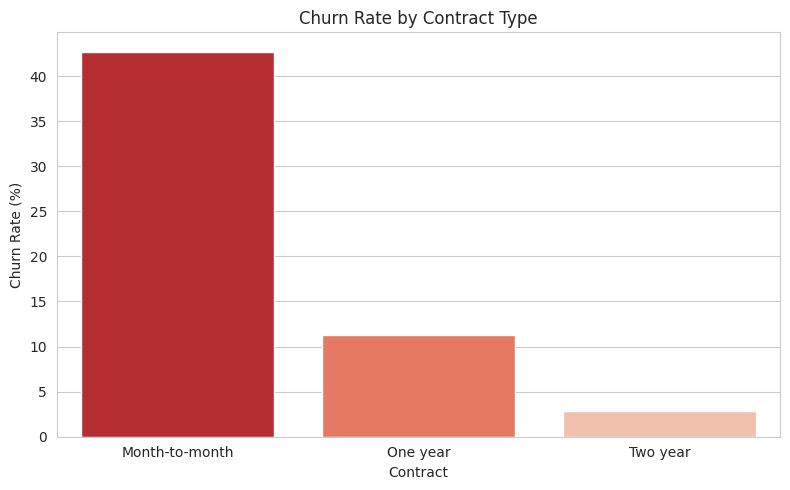

In [7]:
contract_churn = df.groupby('Contract')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='Reds_r')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

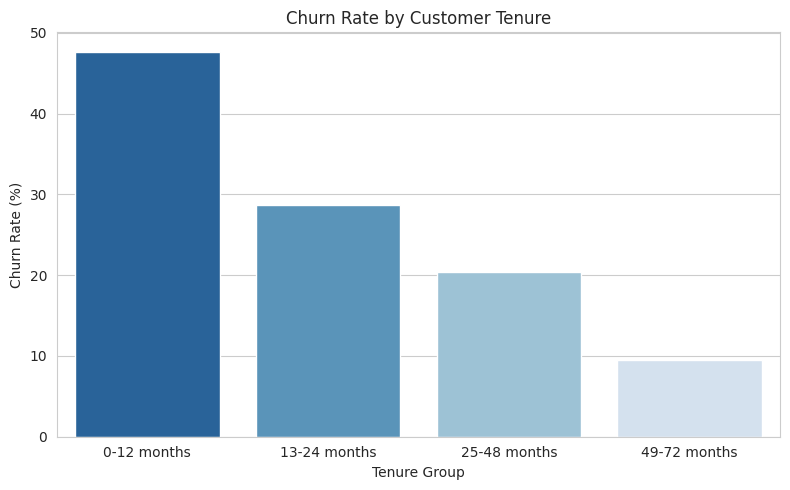

In [8]:
df['Tenure Group'] = pd.cut(df['tenure'],
                             bins=[0,12,24,48,72],
                             labels=['0-12 months','13-24 months','25-48 months','49-72 months'])

tenure_churn = df.groupby('Tenure Group')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, palette='Blues_r')
plt.title('Churn Rate by Customer Tenure')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

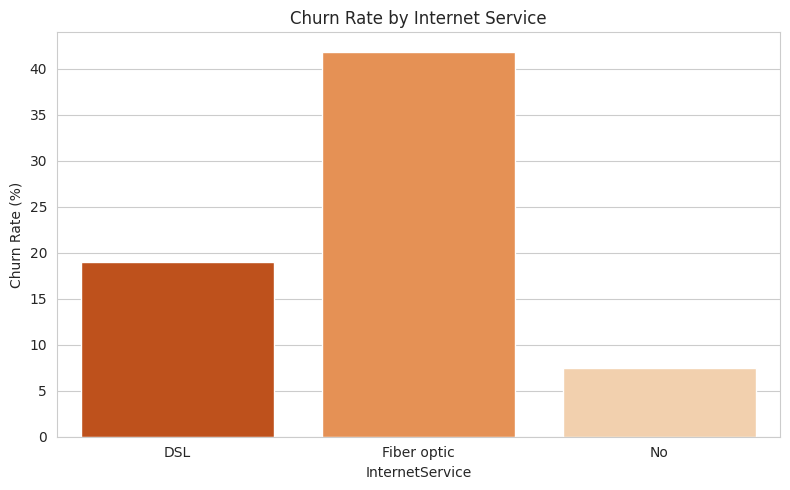

In [9]:
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=internet_churn.index, y=internet_churn.values, palette='Oranges_r')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

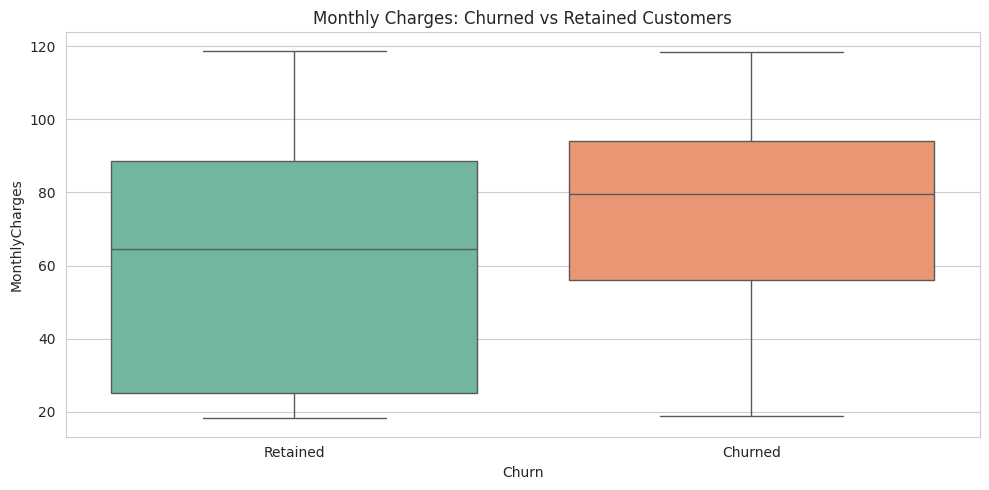

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.title('Monthly Charges: Churned vs Retained Customers')
plt.tight_layout()
plt.show()

In [11]:
total = len(df)
churned = df['Churn'].sum()
churn_rate = df['Churn'].mean() * 100
avg_tenure_churned = df[df['Churn']==1]['tenure'].mean()
avg_tenure_retained = df[df['Churn']==0]['tenure'].mean()
avg_charges_churned = df[df['Churn']==1]['MonthlyCharges'].mean()
high_risk = df[df['Contract']=='Month-to-month']['Churn'].mean() * 100

print(f"Total Customers    : {total}")
print(f"Churned Customers  : {churned}")
print(f"Churn Rate         : {churn_rate:.1f}%")
print(f"Avg Tenure Churned : {avg_tenure_churned:.1f} months")
print(f"Avg Tenure Retained: {avg_tenure_retained:.1f} months")
print(f"Avg Monthly Charges (Churned): ${avg_charges_churned:.2f}")
print(f"Month-to-Month Churn Rate    : {high_risk:.1f}%")

Total Customers    : 7032
Churned Customers  : 1869
Churn Rate         : 26.6%
Avg Tenure Churned : 18.0 months
Avg Tenure Retained: 37.7 months
Avg Monthly Charges (Churned): $74.44
Month-to-Month Churn Rate    : 42.7%
